# LSTM - All Sites

In this notebook, we train an LSTM model to predict dry (0) or wet (1) for a given HJ Andrews River Site 3 days after a given date, using a 30-day sliding window of features.

The dataset combines HOBO sensor readings with discretized discharge values. We track the source of each sample (HOBO vs discretized) and report 3 validations: the full validation set, HOBO-only, and discretized-only.

We apply ADASYN to the training data and use a random train-test split. Sequences are created per site to avoid cross-site boundary contamination.

At the bottom of the notebook, we provide a function for practitioners to run inference with our trained models for an inputted site-date combination.

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)
from imblearn.over_sampling import ADASYN
import optuna
from optuna.visualization.matplotlib import plot_contour, plot_parallel_coordinate
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

## Data Preprocessing

In [2]:
# Data Paths
DRIVERS_PATH = "../data/sciencebase/met_drivers.csv"
OBS_PATH = "../data/sciencebase/obs.csv"
STATIC_PATH = "../data/sciencebase/static_vars.csv"
DEGREES_PATH = "../data/huggingface/degrees.parquet"
ORDER_PATH = "../data/huggingface/nhd_id_stream_order_permanence.csv"

# Load datasets
drivers = pd.read_csv(DRIVERS_PATH)
static_df = pd.read_csv(STATIC_PATH)
obs_df = pd.read_csv(OBS_PATH)
degrees = pd.read_parquet(DEGREES_PATH)
stream_order = pd.read_csv(ORDER_PATH)

# Normalize key types before merging
drivers['NHDPlusID'] = drivers['NHDPlusID'].astype(str)
drivers['Date'] = pd.to_datetime(drivers['Date'])
obs_df['NHDPlusID'] = obs_df['NHDPlusID'].astype(str)
obs_df['Date'] = pd.to_datetime(obs_df['Date'])
static_df['NHDPlusID'] = static_df['NHDPlusID'].astype(str)

# Driver columns (for imputation / filtering below)
DRIVER_COLS = [c for c in drivers.columns if c not in ['NHDPlusID', 'Date']]

obs_df


,NHDPlusID,SiteIDCode,Date,Discharge_CMS,MaxDepth_cm,MaxDepth_Threshold,MaxDepth_Censor,Flow_Status,HoboWetDry0.05
0,55000900130309,GSWS01,1980-01-01,0.045505,NaN,NaN,NaN,NaN,NaN
1,55000900130309,GSWS01,1980-01-02,0.043410,NaN,NaN,NaN,NaN,NaN
2,55000900130309,GSWS01,1980-01-03,0.048592,NaN,NaN,NaN,NaN,NaN
3,55000900130309,GSWS01,1980-01-04,0.061872,NaN,NaN,NaN,NaN,NaN
4,55000900130309,GSWS01,1980-01-05,0.276599,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
159074,55000900237668,HoboSite99,2020-10-25,NaN,NaN,NaN,NaN,NaN,0.0
159075,55000900237668,HoboSite99,2020-10-26,NaN,NaN,NaN,NaN,NaN,0.0
159076,55000900237668,HoboSite99,2020-10-27,NaN,NaN,NaN,NaN,NaN,0.0
159077,55000900130309,WDLookMcRaeID1,2020-07-08,NaN,48.768,0.0,1.0,NaN,NaN


In [3]:
# static_vars.csv is already in wide form (one column per variable).
static_pivot = static_df

# obs.csv is already wide; multiple rows can exist per (NHDPlusID, Date)
# (e.g. one row for HOBO, another for MaxDepth) so collapse them by taking
# the first non-null value per column. SiteIDCode is dropped to match the
# previous pivot_table behaviour.
obs_wide = obs_df.drop(columns='SiteIDCode', errors='ignore').groupby(
    ['NHDPlusID', 'Date'], as_index=False
).first()

# Merge drivers, static features, and degrees into each site's obs
central_df = obs_wide.merge(drivers, on=['NHDPlusID', 'Date'], how='left')
central_df = central_df.merge(static_pivot, on='NHDPlusID', how='left')
central_df = central_df.merge(degrees, on='NHDPlusID', how='left')

# Capture is_hobo BEFORE any fill operations propagate HoboWetDry0.05 across rows.
# is_hobo=1 means HoboWetDry0.05 was actually observed at this (site, date);
# is_hobo=0 means the row will fall back to the discretized discharge label.
central_df["is_hobo"] = central_df["HoboWetDry0.05"].notna().astype(int)

# Sort and forward/back-fill drivers within each site to patch temporal gaps.
# Any driver values still missing after this (sites with no driver coverage at all)
# are left as NaN and will be replaced with 0 after normalization (matching the
# RGCN pipeline's np.nan_to_num(X, 0.0) post-scaling behavior).
central_df = central_df.sort_values(['NHDPlusID', 'Date'])
central_df[DRIVER_COLS] = (
    central_df.groupby('NHDPlusID')[DRIVER_COLS]
    .transform(lambda g: g.ffill().bfill())
)

# Per-site forward/back-fill on MaxDepth obs columns to patch temporal gaps.
# Sites with no MaxDepth observation at all fall back to 0.
OBS_EXTRA_COLS = ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']
central_df[OBS_EXTRA_COLS] = (
    central_df.groupby('NHDPlusID')[OBS_EXTRA_COLS]
    .transform(lambda g: g.ffill().bfill())
)
central_df[OBS_EXTRA_COLS] = central_df[OBS_EXTRA_COLS].fillna(0)

n_missing_drivers = central_df[DRIVER_COLS].isna().any(axis=1).sum()
print(f"Rows still missing at least one driver after ffill/bfill: "
      f"{n_missing_drivers:,} / {len(central_df):,}")

central_df.head()

# Free memory — raw drivers frame no longer needed after the merge
import gc
del drivers
gc.collect()


Rows still missing at least one driver after ffill/bfill: 31,652 / 158,603


0

In [4]:
# Create discharge-based wet/dry and combine with HOBO sensor readings.
# is_hobo was captured in cell 6 BEFORE any fills, so it correctly reflects which
# rows actually had a HOBO sensor observation at that (site, date).
DRY_THRESHOLD = 0.00014
central_df["wetdry_discharge"] = (central_df["Discharge_CMS"] >= DRY_THRESHOLD).astype(int)
central_df["wetdry_status"] = central_df["HoboWetDry0.05"].fillna(central_df["wetdry_discharge"])

central_df["wet_dry_next"] = central_df.groupby('NHDPlusID')["wetdry_status"].shift(-3)
central_df = central_df.dropna(subset='wet_dry_next')

# Drop irrelevant and other target columns
central_df = central_df.drop(columns=["wetdry_discharge", "FromNode", "ToNode", "Flow_Status", "HoboWetDry0.05", "Discharge_CMS"])

print("Final wet/dry distribution:")
print(central_df["wet_dry_next"].value_counts())
print(f"\nSource distribution:")
print(f"  HOBO: {central_df['is_hobo'].sum()}")
print(f"  Discretized: {(central_df['is_hobo'] == 0).sum()}")


Final wet/dry distribution:
wet_dry_next
1.0    150515
0.0      7692
Name: count, dtype: int64

Source distribution:
  HOBO: 2731
  Discretized: 155476


In [5]:
target_col = "wet_dry_next"

df = central_df.copy()

# Identify feature columns (numeric, excluding target and source tracker)
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in [target_col, 'is_hobo']]

# Normalize using nan-aware mean/std so missing values don't contaminate the statistics.
feat_mean = df[feature_cols].mean(skipna=True)
feat_std = df[feature_cols].std(skipna=True).replace(0, 1.0)
df[feature_cols] = (df[feature_cols] - feat_mean) / feat_std
df[feature_cols] = df[feature_cols].fillna(0.0)

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Samples: {len(df)}")


Features (34): ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor', 'etalfalfa', 'etgrass', 'prcp', 'rhmax', 'rhmin', 'sph', 'srad', 'tmax', 'tmin', 'vp', 'ws', 'aspect_ne_pct', 'aspect_sw_pct', 'aspect_nw_pct', 'aspect_se_pct', 'elev_min_cm', 'elev_max_cm', 'elev_median_cm', 'elev_mean_cm', 'slp_median_pct', 'slp_mean_pct', 'curv_median', 'curv_mean', 'ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM', 'In-degree', 'Out-degree', 'wetdry_status']
Samples: 158207


In [6]:
# Create 30-day sliding window sequences per site
seq_len = 30

def create_sequences_by_site(df, site_col, feature_cols, target_col, source_col, seq_len=30):
    """Create sliding window sequences grouped by site, tracking sample source."""
    X, y, sources = [], [], []
    for _, group in df.groupby(site_col):
        if len(group) <= seq_len:
            continue
        features = group[feature_cols].values
        labels = group[target_col].values
        src = group[source_col].values
        for i in range(len(group) - seq_len):
            X.append(features[i:i+seq_len])
            y.append(labels[i + seq_len - 1])
            sources.append(src[i + seq_len - 1])  # source of the target label
    return np.array(X), np.array(y), np.array(sources)

X, y, sources = create_sequences_by_site(
    df, 'NHDPlusID', feature_cols, target_col, 'is_hobo', seq_len=seq_len
)
print(f"Sequences: {X.shape}, Labels: {y.shape}")
print(f"Class distribution — Wet: {int((y > 0.5).sum())}, Dry: {int((y <= 0.5).sum())}")
print(f"Source — HOBO: {int(sources.sum())}, Discretized: {int((sources == 0).sum())}")

Sequences: (157177, 30, 34), Labels: (157177,)
Class distribution — Wet: 149552, Dry: 7625
Source — HOBO: 2102, Discretized: 155075


In [7]:
# Random train-test split (BEFORE ADASYN)
X_train, X_val, y_train, y_val, src_train, src_val = train_test_split(
    X, y, sources, test_size=0.2, shuffle=True, random_state=42
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Val source — HOBO: {int(src_val.sum())}, Discretized: {int((src_val == 0).sum())}")

# ADASYN on training data only (flatten 3D -> 2D, resample, reshape back)
n, T, d = X_train.shape
X_flat = X_train.reshape(n, T * d)
adasyn = ADASYN(random_state=42)
X_flat_res, y_train_res = adasyn.fit_resample(X_flat, y_train.astype(int))
X_train_res = X_flat_res.reshape(-1, T, d)

print(f"\nOriginal train class counts: {np.bincount(y_train.astype(int))}")
print(f"After ADASYN: {np.bincount(y_train_res.astype(int))}")

# Convert to tensors
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

print(f"\nX_train_tensor: {X_train_tensor.shape}, X_val_tensor: {X_val_tensor.shape}")

# Free memory — ADASYN intermediates and raw arrays no longer needed
import gc
del X_flat, X_flat_res, X_train_res
gc.collect()

Train: (125741, 30, 34), Val: (31436, 30, 34)
Val source — HOBO: 401, Discretized: 31035

Original train class counts: [  6072 119669]
After ADASYN: [119067 119669]

X_train_tensor: torch.Size([238736, 30, 34]), X_val_tensor: torch.Size([31436, 30, 34])


0

## Hyperparameter Selection

[I 2026-05-01 00:52:10,847] A new study created in memory with name: no-name-ae37a7e1-9bb7-4d53-9122-08b2f1c2d447


Optuna subset — Train: torch.Size([20000, 30, 34]), Val: torch.Size([20000, 30, 34])


[I 2026-05-01 00:53:06,918] Trial 0 finished with value: 0.012982401705835422 and parameters: {'hidden_size': 59, 'num_layers': 1, 'dropout': 0.16113656000877963, 'lr': 0.005121565917275336, 'batch_size': 32}. Best is trial 0 with value: 0.012982401705835422.
[I 2026-05-01 00:55:21,003] Trial 1 finished with value: 0.012477925172147186 and parameters: {'hidden_size': 127, 'num_layers': 2, 'dropout': 0.39295860846566055, 'lr': 0.00023241725457183546, 'batch_size': 64}. Best is trial 1 with value: 0.012477925172147186.
[I 2026-05-01 00:57:23,255] Trial 2 finished with value: 0.01165143409420899 and parameters: {'hidden_size': 57, 'num_layers': 2, 'dropout': 0.14975965652742823, 'lr': 0.007658805357820028, 'batch_size': 64}. Best is trial 2 with value: 0.01165143409420899.
[I 2026-05-01 01:00:33,114] Trial 3 finished with value: 0.011669622157789883 and parameters: {'hidden_size': 127, 'num_layers': 1, 'dropout': 0.2568475886728699, 'lr': 0.005217502124364217, 'batch_size': 16}. Best is t


Best Hyperparameters:
{'hidden_size': 57, 'num_layers': 2, 'dropout': 0.14975965652742823, 'lr': 0.007658805357820028, 'batch_size': 64}
Best Validation AUC: 0.9883


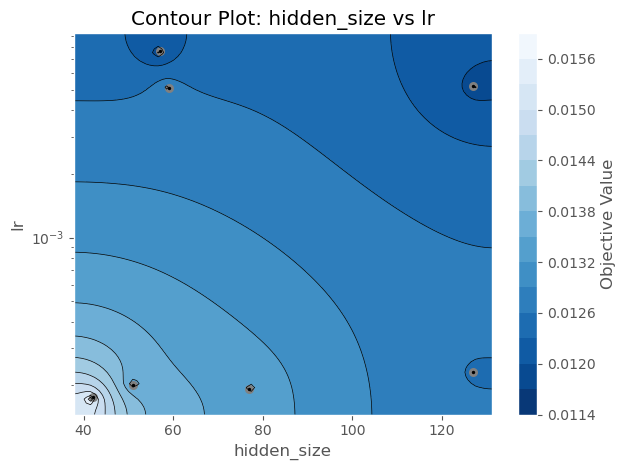

In [ ]:
# Toggle: skip Optuna and use previously found hyperparameters
SKIP_OPTUNA = False
OPTUNA_BEST_PARAMS = {
    'hidden_size': 57,
    'num_layers': 2,
    'dropout': 0.15,
    'lr': 0.008,
    'batch_size': 64
}

if SKIP_OPTUNA:
    best_params = OPTUNA_BEST_PARAMS
    print("Skipping Optuna — using saved hyperparameters:")
    print(best_params)

else:
    # Use a small random subset for faster Optuna search
    HP_SAMPLE_SIZE = 20000
    hp_train_idx = np.random.choice(len(X_train_tensor), min(HP_SAMPLE_SIZE, len(X_train_tensor)), replace=False)
    hp_val_idx = np.random.choice(len(X_val_tensor), min(HP_SAMPLE_SIZE, len(X_val_tensor)), replace=False)
    X_hp_train = X_train_tensor[hp_train_idx]
    y_hp_train = y_train_tensor[hp_train_idx]
    X_hp_val = X_val_tensor[hp_val_idx]
    y_hp_val = y_val_tensor[hp_val_idx]
    print(f"Optuna subset — Train: {X_hp_train.shape}, Val: {X_hp_val.shape}")

    # LSTM model for Optuna (with sigmoid output)
    class LSTMModelHP(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, dropout):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
            self.fc = nn.Linear(hidden_size, 1)
            self.sigmoid = nn.Sigmoid()
        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.fc(out[:, -1, :])
            return self.sigmoid(out)

    # Optuna objective
    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 32, 128)
        num_layers  = trial.suggest_int("num_layers", 1, 3)
        dropout     = trial.suggest_float("dropout", 0.0, 0.4)
        lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size  = trial.suggest_categorical("batch_size", [16, 32, 64])
        epochs      = 2

        model = LSTMModelHP(
            input_size=X_hp_train.shape[2],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        )
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        train_loader = DataLoader(TensorDataset(X_hp_train, y_hp_train), batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            model.train()
            for xb, yb in train_loader:
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_hp_val).squeeze(-1).cpu().numpy()
            val_true = y_hp_val.squeeze(-1).cpu().numpy()

        if len(np.unique(val_true)) < 2:
            return 1.0

        auc = roc_auc_score(val_true, val_preds)
        return 1 - auc  # minimize (1 - AUC)

    # Run Optuna study
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=7)

    best_params = study.best_params
    print("\nBest Hyperparameters:")
    print(best_params)
    print(f"Best Validation AUC: {1 - study.best_value:.4f}")

    # Contour plot of hyperparameter interactions
    fig = plot_contour(
        study,
        params=["hidden_size", "lr"]
    )
    plt.title("Contour Plot: hidden_size vs lr")
    plt.tight_layout()
    plt.show()

## Model Training

In [9]:
# Toggle: load pre-trained weights instead of training
LOAD_WEIGHTS = False
WEIGHTS_PATH = "/Users/michaelmurphy/Desktop/usgs_data/lstm_all_sites_weights.pt"

# Toggle: use Optuna-found hyperparameters or defaults
USE_OPTUNA = True

if USE_OPTUNA:
    hidden_size = best_params['hidden_size']
    num_layers  = best_params['num_layers']
    dropout     = best_params['dropout']
    lr          = best_params['lr']
    batch_size  = best_params['batch_size']
    print(f"Using Optuna params: hidden_size={hidden_size}, num_layers={num_layers}, "
          f"dropout={dropout:.4f}, lr={lr:.6f}, batch_size={batch_size}")
else:
    hidden_size = 48
    num_layers = 1
    dropout = 0.2
    lr = 1e-4
    batch_size = 32
    print(f"Using default params: hidden_size={hidden_size}, num_layers={num_layers}, "
          f"dropout={dropout}, lr={lr}, batch_size={batch_size}")

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

# Define LSTM model (logits output for BCEWithLogitsLoss)
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = LSTMModel(input_size=len(feature_cols), hidden_size=hidden_size,
                  num_layers=num_layers, dropout=dropout)

if LOAD_WEIGHTS:
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))
    model.eval()
    print(f"Loaded weights from '{WEIGHTS_PATH}' — skipping training.")

else:
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]))
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training with early stopping
    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0
    epochs = 1

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
                val_loss += criterion(logits, yb).item()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss={total_loss/len(train_loader):.4f} | Val Loss={val_loss/len(val_loader):.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    print("Loaded best model state.")

Using Optuna params: hidden_size=57, num_layers=2, dropout=0.1498, lr=0.007659, batch_size=64
Epoch 1/1 | Train Loss=0.1840 | Val Loss=0.1487
Loaded best model state.


## Metrics and Feature Importance

In [10]:
# Prediction helper
def get_predictions(model, X, y):
    """Get predictions for a set of inputs."""
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32) if not isinstance(X, torch.Tensor) else X
    with torch.no_grad():
        logits = model(X_t).squeeze()
        logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
        probs = torch.sigmoid(logits).numpy()
    preds = (probs >= 0.5).astype(int)
    y_true = y.astype(int) if isinstance(y, np.ndarray) else y.squeeze().numpy().astype(int)
    return y_true, preds, probs

def print_metrics(name, y_true, y_pred, y_probs):
    print(f"\n{'='*50}")
    print(f"{name} (n={len(y_true)})")
    print(f"{'='*50}")
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan')
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {roc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_true, y_pred, labels=[0, 1],
                                target_names=['Dry', 'Wet'], digits=3, zero_division=0))
    return acc, roc, f1

# Split validation set by source
hobo_mask = src_val == 1
disc_mask = src_val == 0

# 1. Full validation set
y_true_all, y_pred_all, y_probs_all = get_predictions(model, X_val, y_val)
acc_all, roc_all, f1_all = print_metrics("ALL VALIDATION (HOBO + Discretized)", y_true_all, y_pred_all, y_probs_all)

# 2. HOBO-only validation
y_true_hobo, y_pred_hobo, y_probs_hobo = get_predictions(model, X_val[hobo_mask], y_val[hobo_mask])
acc_hobo, roc_hobo, f1_hobo = print_metrics("HOBO-ONLY VALIDATION", y_true_hobo, y_pred_hobo, y_probs_hobo)

# 3. Discretized-only validation
y_true_disc, y_pred_disc, y_probs_disc = get_predictions(model, X_val[disc_mask], y_val[disc_mask])
acc_disc, roc_disc, f1_disc = print_metrics("DISCRETIZED-ONLY VALIDATION", y_true_disc, y_pred_disc, y_probs_disc)

# Summary table
results_df = pd.DataFrame({
    'Validation Set': ['All (HOBO + Disc)', 'HOBO Only', 'Discretized Only'],
    'N': [len(y_true_all), int(hobo_mask.sum()), int(disc_mask.sum())],
    'Accuracy': [acc_all, acc_hobo, acc_disc],
    'ROC-AUC': [roc_all, roc_hobo, roc_disc],
    'F1': [f1_all, f1_hobo, f1_disc]
})
print(f"\n{'='*50}")
print("Summary")
print('='*50)
print(results_df.to_string(index=False))


ALL VALIDATION (HOBO + Discretized) (n=31436)
Accuracy: 0.9669
ROC-AUC:  0.9536
F1 Score: 0.9823
              precision    recall  f1-score   support

         Dry      0.606     0.939     0.737      1553
         Wet      0.997     0.968     0.982     29883

    accuracy                          0.967     31436
   macro avg      0.802     0.954     0.860     31436
weighted avg      0.977     0.967     0.970     31436


HOBO-ONLY VALIDATION (n=401)
Accuracy: 0.9526
ROC-AUC:  0.9657
F1 Score: 0.9705
              precision    recall  f1-score   support

         Dry      0.793     0.986     0.879        70
         Wet      0.997     0.946     0.971       331

    accuracy                          0.953       401
   macro avg      0.895     0.966     0.925       401
weighted avg      0.961     0.953     0.955       401


DISCRETIZED-ONLY VALIDATION (n=31035)
Accuracy: 0.9671
ROC-AUC:  0.9526
F1 Score: 0.9825
              precision    recall  f1-score   support

         Dry      0.59

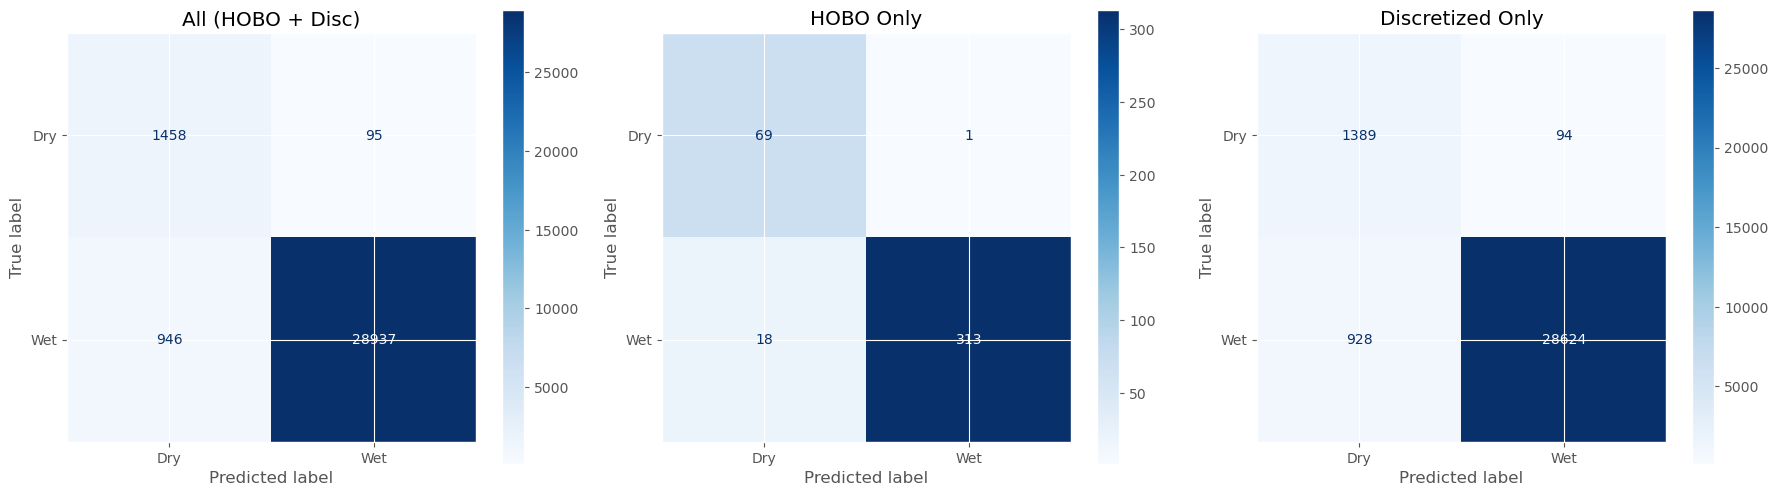

In [11]:
# Confusion matrices for all 3 validation sets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_t, y_p) in zip(axes, [
    ('All (HOBO + Disc)', y_true_all, y_pred_all),
    ('HOBO Only', y_true_hobo, y_pred_hobo),
    ('Discretized Only', y_true_disc, y_pred_disc)
]):
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()

           Feature  Importance
     lagged_target    0.046933
              srad    0.013011
           etgrass    0.006464
         etalfalfa    0.005381
                vp    0.005381
             rhmax    0.004300
               sph    0.004300
     aspect_ne_pct    0.003222
              prcp    0.003222
   MaxDepth_Censor    0.002146
              tmax   -0.002137
          AreaSqKm   -0.002137
          LengthKM    0.001072
        ArbolateSu    0.001072
       MaxDepth_cm    0.001072
             rhmin    0.001072
       curv_median   -0.001069
    elev_median_cm   -0.001069
    slp_median_pct   -0.001069
         curv_mean   -0.001069
                ws    0.000000
        out_degree    0.000000
         in_degree    0.000000
             Slope    0.000000
         TotDASqKm    0.000000
              tmin    0.000000
     aspect_sw_pct    0.000000
     aspect_nw_pct    0.000000
      slp_mean_pct    0.000000
      elev_mean_cm    0.000000
       elev_max_cm    0.000000
       e

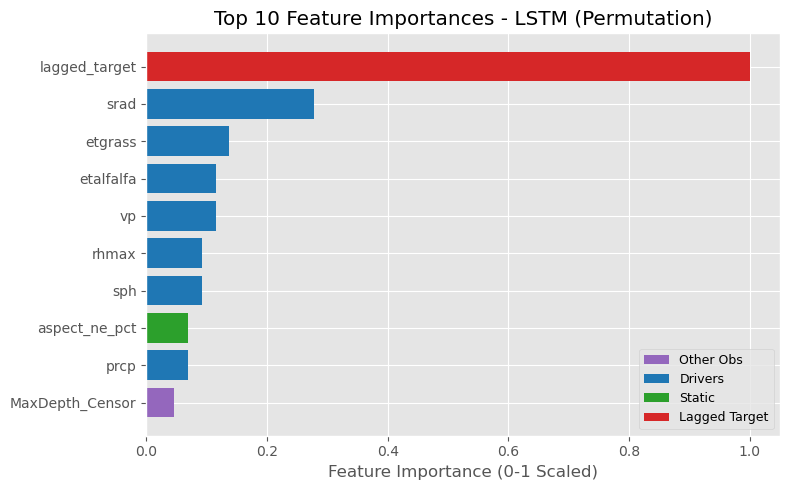

In [12]:
# Permutation importance
def perm_importance(model, X_val_tensor, y_val, n_repeats=1, n_samples=500):
    model.eval()

    # Subsample validation set for speed
    if n_samples is not None and n_samples < X_val_tensor.shape[0]:
        idx = torch.randperm(X_val_tensor.shape[0])[:n_samples]
        X_val_tensor = X_val_tensor[idx]
        y_val = y_val[idx]

    with torch.no_grad():
        base_preds = torch.sigmoid(model(X_val_tensor)).cpu().numpy()
        base_f1 = f1_score(y_val, (base_preds > 0.5))

        importances = []
        for col in range(X_val_tensor.shape[2]):
            f1_scores = []
            for _ in range(n_repeats):
                X_permuted = X_val_tensor.clone()
                X_permuted[:, :, col] = X_val_tensor[:, :, col][torch.randperm(X_val_tensor.shape[0])]
                perm_preds = torch.sigmoid(model(X_permuted)).cpu().numpy()
                f1_scores.append(f1_score(y_val, (perm_preds > 0.5)))
            importances.append(base_f1 - np.mean(f1_scores))

    return np.array(importances)

imps = perm_importance(model, X_val_tensor, y_val.astype(int))

importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": imps
})
importance['Abs_Importance'] = importance['Importance'].abs()
importance = importance.sort_values('Abs_Importance', ascending=False)
importance['Importance_Scaled'] = importance['Abs_Importance'] / importance['Abs_Importance'].max()

importance['Feature'] = importance['Feature'].replace({
    'wetdry_status': 'lagged_target',
    'Out-degree': 'out_degree',
    'In-degree': 'in_degree',
})

print(importance[['Feature', 'Importance']].to_string(index=False))

# Color-code feature importances by category (consistent across notebooks)
from matplotlib.patches import Patch

FEATURE_CATEGORIES = {
    'lagged_target': 'Lagged Target',
    'in_degree': 'Degrees',
    'out_degree': 'Degrees',
}
for v in ['tmax', 'tmin', 'srad', 'prcp', 'vp', 'ws',
          'etgrass', 'etalfalfa', 'rhmax', 'rhmin', 'sph']:
    FEATURE_CATEGORIES[v] = 'Drivers'
for v in ['ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM',
          'FromNode', 'ToNode',
          'aspect_ne_pct', 'aspect_nw_pct', 'aspect_se_pct', 'aspect_sw_pct',
          'curv_mean', 'curv_median',
          'elev_max_cm', 'elev_mean_cm', 'elev_median_cm', 'elev_min_cm',
          'slp_mean_pct', 'slp_median_pct']:
    FEATURE_CATEGORIES[v] = 'Static'
for v in ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']:
    FEATURE_CATEGORIES[v] = 'Other Obs'

CATEGORY_COLORS = {
    'Lagged Target': '#d62728',  # red
    'Drivers':       '#1f77b4',  # blue
    'Static':        '#2ca02c',  # green
    'Degrees':       '#ff7f0e',  # orange
    'Other Obs':     '#9467bd',  # purple
    'Other':         '#7f7f7f',  # gray
}

def feature_color(name):
    return CATEGORY_COLORS[FEATURE_CATEGORIES.get(name, 'Other')]

def add_category_legend(ax, features):
    seen = []
    for f in features:
        cat = FEATURE_CATEGORIES.get(f, 'Other')
        if cat not in seen:
            seen.append(cat)
    handles = [Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in seen]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True)

top10 = importance.head(10)
features_top = top10['Feature'][::-1].tolist()
values_top   = top10['Importance_Scaled'][::-1].tolist()
bar_colors   = [feature_color(f) for f in features_top]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features_top, values_top, color=bar_colors)
ax.set_xlabel('Feature Importance (0-1 Scaled)')
ax.set_title('Top 10 Feature Importances - LSTM (Permutation)')
add_category_legend(ax, features_top)
plt.tight_layout()
plt.show()

## Stream Order Comparison

This section compares model performance between headwater (stream order ≤ 2) and tailwater (stream order ≥ 3) segments. Stream order is taken from the NHD value-added attributes: lower orders (1–2) are higher in the network (headwaters), higher orders (3+) are further downstream (tailwaters).

We filter `stream_order` to segments with observed data (`has_data=True`) and track which validation sequences belong to each group by propagating `NHDPlusID` through the same train/test split used during training.

In [13]:
# Extract NHDPlusID per sequence using the same groupby order as create_sequences_by_site
nhd_ids_all = []
for _, group in df.groupby('NHDPlusID'):
    if len(group) <= seq_len:
        continue
    nhd_id = group['NHDPlusID'].values
    for i in range(len(group) - seq_len):
        nhd_ids_all.append(nhd_id[i + seq_len - 1])
nhd_ids_all = np.array(nhd_ids_all)

# Split with identical parameters to produce ids_val aligned with X_val / y_val / src_val
_, ids_val = train_test_split(nhd_ids_all, test_size=0.2, shuffle=True, random_state=42)

print(f"Total sequences: {len(nhd_ids_all)}")
print(f"Validation sequences: {len(ids_val)}")
print(f"Unique validation sites: {len(np.unique(ids_val))}")

Total sequences: 157177
Validation sequences: 31436
Unique validation sites: 34


In [14]:
# Filter stream_order to segments with observed data
stream_order_data = stream_order[stream_order['has_data'] == True].copy()

# Map NHDPlusID -> StreamOrde for each validation sequence
order_map = stream_order_data.set_index(
    stream_order_data['NHDPlusID'].astype(str)
)['StreamOrde'].to_dict()

val_orders = np.array([order_map.get(str(nhd), np.nan) for nhd in ids_val])

# Headwater / tailwater masks
hw_mask = val_orders <= 2
tw_mask = val_orders >= 3
known_mask = ~np.isnan(val_orders)

print(f"Validation sequences with known stream order: {known_mask.sum()}")
print(f"  Headwaters (order ≤ 2): {hw_mask.sum()}")
print(f"  Tailwaters (order ≥ 3): {tw_mask.sum()}")
print(f"  No stream order data:   {(~known_mask).sum()}")

Validation sequences with known stream order: 25194
  Headwaters (order ≤ 2): 12380
  Tailwaters (order ≥ 3): 12814
  No stream order data:   6242


In [15]:
# Headwaters
y_true_hw, y_pred_hw, y_probs_hw = get_predictions(model, X_val[hw_mask], y_val[hw_mask])
acc_hw, roc_hw, f1_hw = print_metrics("HEADWATERS (Order ≤ 2)", y_true_hw, y_pred_hw, y_probs_hw)

# Tailwaters
y_true_tw, y_pred_tw, y_probs_tw = get_predictions(model, X_val[tw_mask], y_val[tw_mask])
acc_tw, roc_tw, f1_tw = print_metrics("TAILWATERS (Order ≥ 3)", y_true_tw, y_pred_tw, y_probs_tw)

# Summary table
stream_order_results = pd.DataFrame({
    'Group': ['Headwaters (≤ 2)', 'Tailwaters (≥ 3)'],
    'N': [int(hw_mask.sum()), int(tw_mask.sum())],
    'Accuracy': [acc_hw, acc_tw],
    'ROC-AUC': [roc_hw, roc_tw],
    'F1': [f1_hw, f1_tw]
})
print(f"\n{'='*50}")
print("Stream Order Summary")
print('='*50)
print(stream_order_results.to_string(index=False))


HEADWATERS (Order ≤ 2) (n=12380)
Accuracy: 0.9529
ROC-AUC:  0.9586
F1 Score: 0.9746
              precision    recall  f1-score   support

         Dry      0.530     0.965     0.684       655
         Wet      0.998     0.952     0.975     11725

    accuracy                          0.953     12380
   macro avg      0.764     0.959     0.829     12380
weighted avg      0.973     0.953     0.959     12380


TAILWATERS (Order ≥ 3) (n=12814)
Accuracy: 0.9930
ROC-AUC:  0.9466
F1 Score: 0.9965
              precision    recall  f1-score   support

         Dry      0.237     0.900     0.375        30
         Wet      1.000     0.993     0.996     12784

    accuracy                          0.993     12814
   macro avg      0.618     0.947     0.686     12814
weighted avg      0.998     0.993     0.995     12814


Stream Order Summary
           Group     N  Accuracy  ROC-AUC       F1
Headwaters (≤ 2) 12380  0.952908 0.958562 0.974556
Tailwaters (≥ 3) 12814  0.992976 0.946597 0.996468


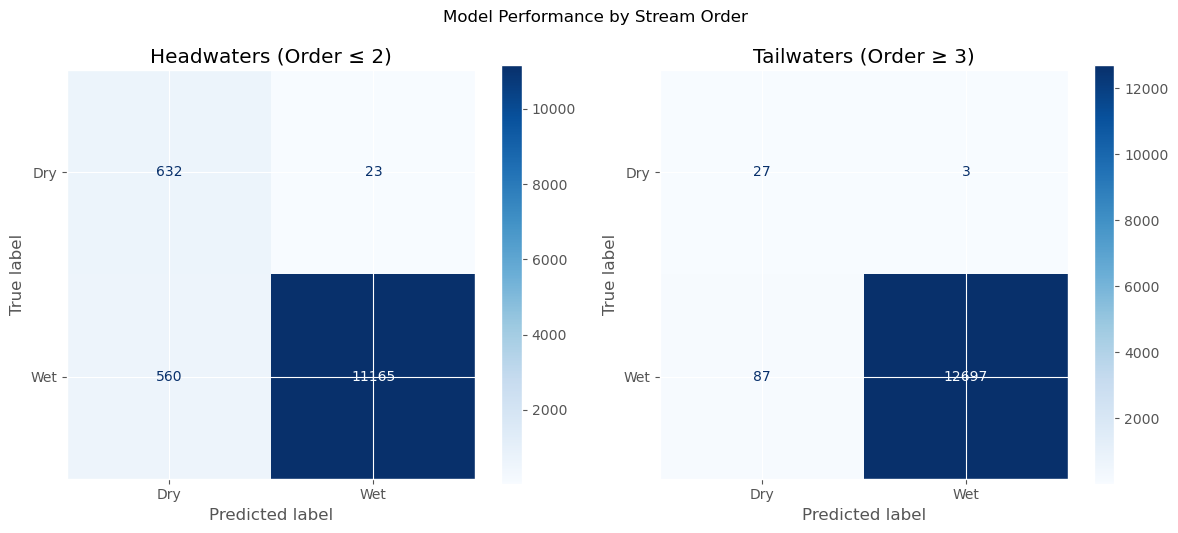

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_t, y_p) in zip(axes, [
    ('Headwaters (Order ≤ 2)', y_true_hw, y_pred_hw),
    ('Tailwaters (Order ≥ 3)', y_true_tw, y_pred_tw)
]):
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(name)

plt.suptitle('Model Performance by Stream Order', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Metrics and predictions per individual stream order
order_values = sorted(int(o) for o in np.unique(val_orders[~np.isnan(val_orders)]))

per_order_preds = {}   # order -> (y_true, y_pred, y_probs)
per_order_stats = []   # for summary table and bar chart

for order in order_values:
    mask = val_orders == order
    if mask.sum() == 0:
        continue
    yt, yp, yprobs = get_predictions(model, X_val[mask], y_val[mask])
    acc, roc, f1 = print_metrics(f"STREAM ORDER {order}", yt, yp, yprobs)
    per_order_preds[order] = (yt, yp, yprobs)
    per_order_stats.append({
        'Stream Order': order,
        'N': int(mask.sum()),
        'Accuracy': acc,
        'ROC-AUC': roc,
        'F1': f1,
    })

per_order_df = pd.DataFrame(per_order_stats)
print(f"\n{'='*50}")
print("Per-Order Summary")
print('='*50)
print(per_order_df.to_string(index=False))


STREAM ORDER 1 (n=3374)
Accuracy: 0.9431
ROC-AUC:  0.9545
F1 Score: 0.9673
              precision    recall  f1-score   support

         Dry      0.655     0.969     0.781       354
         Wet      0.996     0.940     0.967      3020

    accuracy                          0.943      3374
   macro avg      0.825     0.954     0.874      3374
weighted avg      0.960     0.943     0.948      3374


STREAM ORDER 2 (n=9006)
Accuracy: 0.9566
ROC-AUC:  0.9583
F1 Score: 0.9771
              precision    recall  f1-score   support

         Dry      0.433     0.960     0.596       301
         Wet      0.999     0.956     0.977      8705

    accuracy                          0.957      9006
   macro avg      0.716     0.958     0.787      9006
weighted avg      0.980     0.957     0.964      9006


STREAM ORDER 3 (n=6470)
Accuracy: 0.9861
ROC-AUC:  0.9432
F1 Score: 0.9930
              precision    recall  f1-score   support

         Dry      0.237     0.900     0.375        30
         

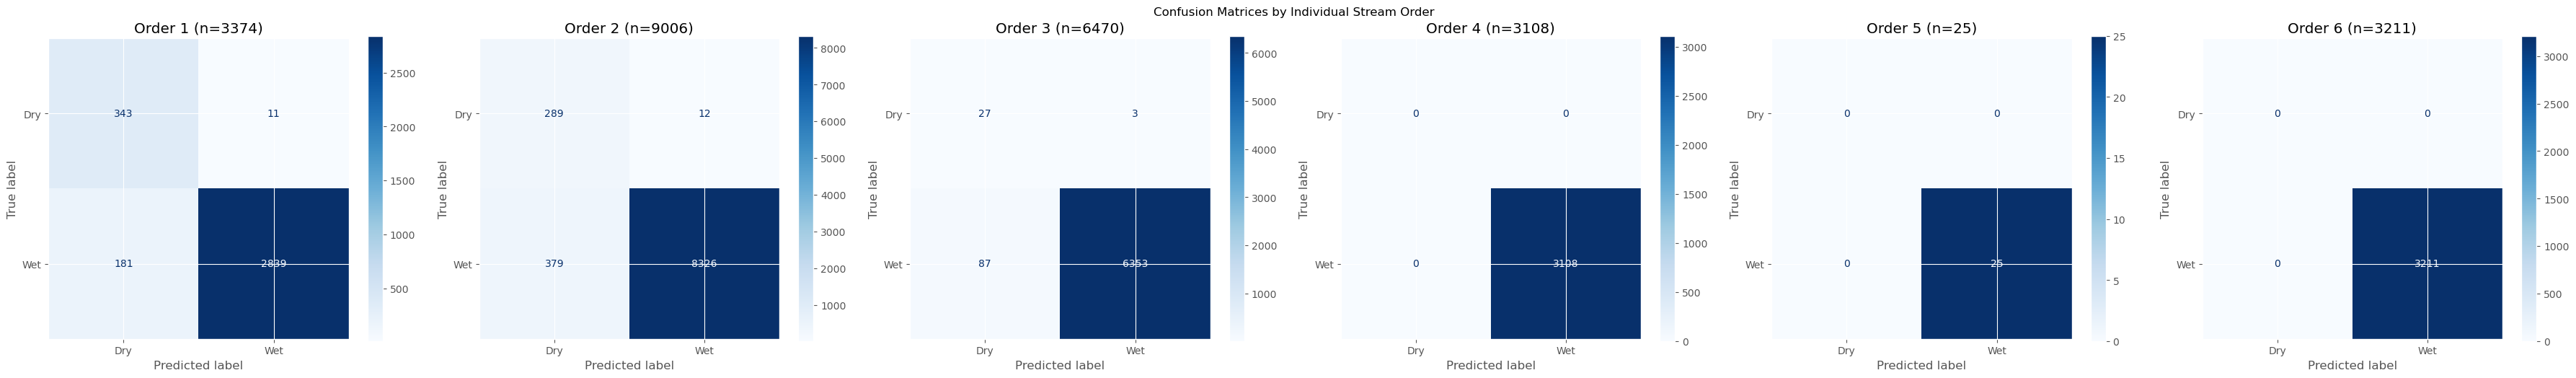

In [18]:
n_orders = len(per_order_preds)
fig, axes = plt.subplots(1, n_orders, figsize=(6 * n_orders, 5))
if n_orders == 1:
    axes = [axes]

for ax, (order, (yt, yp, _)) in zip(axes, per_order_preds.items()):
    n_seq = next(r['N'] for r in per_order_stats if r['Stream Order'] == order)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'Order {order} (n={n_seq})')

plt.suptitle('Confusion Matrices by Individual Stream Order')
plt.tight_layout()
plt.show()

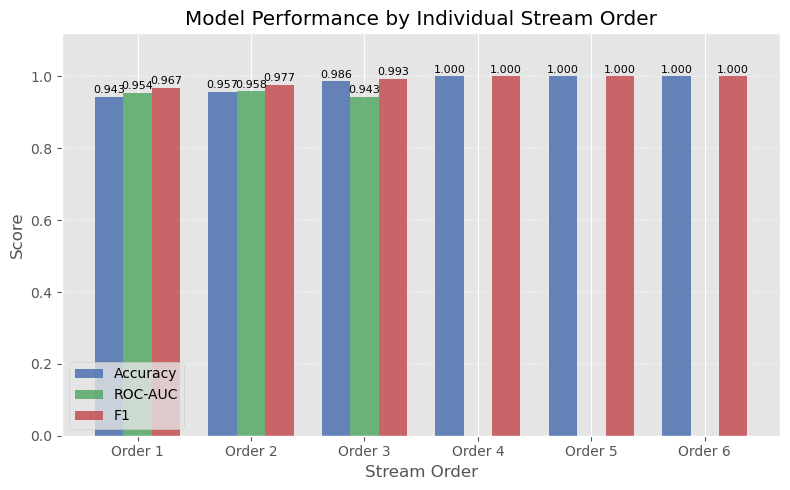

In [19]:
metrics = ['Accuracy', 'ROC-AUC', 'F1']
orders = [r['Stream Order'] for r in per_order_stats]
x = np.arange(len(orders))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [r[metric] for r in per_order_stats]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Stream Order')
ax.set_ylabel('Score')
ax.set_title('Model Performance by Individual Stream Order')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Order {o}' for o in orders])
ax.set_ylim(0, 1.12)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Inference

In [20]:
def predict_site_date_lstm(model, scaler, site_df, seq_len, site_id, date, target_col="wet_dry_next", days_ahead=3):
    """
    Predict wet/dry status for a given site and date using LSTM.
    
    Parameters:
    -----------
    model : LSTMModel
        Trained LSTM model
    scaler : StandardScaler
        Fitted scaler for feature normalization
    site_df : pd.DataFrame
        Complete dataset for the site with all features
    seq_len : int
        Sequence length used in training (e.g., 30)
    site_id : str
        Site identifier (e.g., "55000900061097")
    date : str
        Date in format "YYYY-MM-DD"
    target_col : str
        Target column name
    
    Returns:
    --------
    str : Prediction result with probability
    """
    date = pd.to_datetime(date).date()
    site_id = str(site_id)
    
    # Get site data
    site_data = site_df[site_df["NHDPlusID"] == site_id].sort_values("Date")
    
    if site_data.empty:
        return f"No data found for Site {site_id}"
    
    # Find the date index
    date_idx = site_data[site_data["Date"] == date].index
    
    if len(date_idx) == 0:
        return f"No data found for Site {site_id} on {date}"
    
    date_idx = date_idx[0]
    date_pos = site_data.index.get_loc(date_idx)
    
    # Check if we have enough history
    if date_pos < seq_len:
        return f"Not enough historical data (need {seq_len} days) for {date}"
    
    # Extract sequence
    seq_data = site_data.iloc[date_pos - seq_len:date_pos]
    
    # Prepare features
    df_numeric = seq_data.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
    seq_scaled = scaler.transform(df_numeric)
    
    # Convert to tensor
    seq_tensor = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, features)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(seq_tensor)
        prob = torch.sigmoid(logits).item()
    
    pred_class = 1 if prob >= 0.5 else 0
    
    return f"Site {site_id}, {days_ahead} days after {date}: {'DRY' if pred_class == 0 else 'WET'}, (P(wet)={prob:.4f})"

In [21]:
# # Example inference
# predict_site_date_lstm(
#     model=model,
#     scaler=scaler,
#     site_df=central_df.drop(columns=["is_hobo"]),
#     seq_len=30,
#     site_id="55000900272714",
#     date="2020-10-18",
#     target_col="wet_dry_next"
# )